# H-004 · Book construction: frozen vs quarterly rotating

Bake-off of **how the pair book is chosen**. Everything else is held identical, so this is a
single-variable test.

| | `freeze` | `rotate` |
|---|---|---|
| Screen date(s) | once at `RESEARCH_IS_END` | every quarter-end session |
| Screen window | **full IS** (`date <= T`) | trailing **`L = 252`** bars |
| Book | fixed for the whole evaluation | re-selected each rebalance |
| α / ranking / caps | 0.05, lowest p-value, 6 global & 2 per pool | identical |

The window asymmetry is deliberate: full IS *is* what freezing means here ("cointegrated in
general"), while the trailing year is what rotation means ("cointegrated recently"). Forcing both
to `L = 252` would handicap `freeze`.

**Economic rationale.** Universe C showed Engle-Granger passing once at discovery while rolling ADF
stayed insignificant 71–89% of the time. Freezing keeps trading a dead relationship; rotation is
the direct structural fix. The counter-risk is selection noise from repeated screening, which the
caps and p-value ranking bound.

## Pre-registered constants (not searched, not STARs)

Quarterly rebalance · `L = 252` trailing bars · `alpha = 0.05` · global cap **6** · per-pool cap
**2** · fixed **`1/6`** slot weighting · beta-hedged legs · `BREAK_STAR` health gate from H-003.

- **No half-life filter** (deferred to H-008) — selection ranks on p-value only.
- **No min tenure** — demotion never forces a trade, so there is nothing to damp.
- **Demotion:** blocked from **new** entries; open positions run to their normal z-exit.
- **Orientation flip:** demote-then-promote. The old side is blocked and runs to z-exit; the new
  side waits until the old is flat. One slot per unordered pair either way.
- **Short bans** apply in both arms and compose with the demotion mask by logical AND.

## Metrics and decision

Report `ann_sharpe_gross`, `ann_sharpe_net`, max DD, `corr_to_s1`, active pairs per quarter,
promotions / demotions, and **book composition by pool**. `cost_bps_year` is dropped: the
gross-vs-net gap says the same thing more directly (C was gross ≈ 0 / net ≈ −0.5).

Rank on **net Sharpe**; read correlation beside it. **A negative correlation to S1 is strictly
better than a low positive one** (−0.2 beats 0.0). No combined score.

**Continue / shelve.** Winner = higher median fold-val Sharpe. If the **winning** arm's median
fold-val Sharpe ≤ 0, shelve this universe and return to the next-ranked H-001 universe instead of
proceeding to H-005.

## 0. Imports & Config

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s2_coint.diagnosis import gross_returns_from_net
from backtest.s2_coint.report import (
    load_star_stack,
    plot_fold_boxplots,
    require_star,
    save_star_stack,
    write_tearsheet_pdf,
)
from backtest.s2_coint.research import (
    ARTIFACTS_DIR,
    DEFAULT_STAR_STACK,
    config_from_stack,
    frozen_pairs_for_universe,
    is_end_for_stack,
    load_s1_weekly,
    load_universe_panels,
    long_ohlcv_to_frames,
    lookbacks_for_bar,
    overlay_ols_hedge,
    rebalance_path,
    tearsheet_path,
)
from backtest.s2_coint.rotation import (
    book_composition,
    build_active_schedule,
    freeze_book,
    quarter_end_rebalance_dates,
    schedule_to_masks,
    simulate_frozen_book,
    simulate_rotating_book,
)
from backtest.s2_coint.walkforward import embargo_bars_for_config, make_s2_folds
from data.ingestion.equity_fetcher import fetch_ohlcv
from data.processing.s2_universe import (
    iter_pool_pairs,
    load_s2_pools,
    pool_tickers,
    ticker_venue_key,
)
from strategies.s2_coint.book import (
    CAP_GLOBAL,
    CAP_PER_POOL,
    DISCOVERY_LOOKBACK_BARS,
    SLOT_WEIGHT,
)
from strategies.s2_coint.metrics import corr_to_s1, metrics_from_returns

STAR_PATH = DEFAULT_STAR_STACK
TEARSHEET_DIR = ARTIFACTS_DIR
stack = load_star_stack(STAR_PATH)

require_star("UNIVERSE_STAR", stack.get("UNIVERSE_STAR"))
require_star("BAR_STAR", stack.get("BAR_STAR"))
require_star("BREAK_STAR", stack.get("BREAK_STAR"))
UNIVERSE = str(stack["UNIVERSE_STAR"])
BAR = str(stack["BAR_STAR"])

COINT_PVALUE = 0.05
START_DATE = "2000-01-01"

POOLS = load_s2_pools(UNIVERSE)
CANDIDATES = iter_pool_pairs(POOLS)

print("universe", UNIVERSE, "bar", BAR, "break", stack["BREAK_STAR"])
print("candidates", len(CANDIDATES), "tickers", len(pool_tickers(POOLS)))
print(
    "caps: global", CAP_GLOBAL, "per pool", CAP_PER_POOL,
    "| L", DISCOVERY_LOOKBACK_BARS, "| slot weight", round(SLOT_WEIGHT, 4),
)

universe D bar 1d break block_05_flat_10
candidates 10 tickers 20
caps: global 6 per pool 2 | L 252 | slot weight 0.1667


## 1. Fetch closes and build both books

Screening needs **closes only** — no panel. `freeze` screens the full IS at `RESEARCH_IS_END`;
`rotate` screens each quarter-end on the trailing `L = 252` bars. The **union** of the two books is
what the panel then has to cover.

In [2]:
tickers = pool_tickers(POOLS)
frames = {}
for ticker in tickers:
    # Exchange-suffixed names keep their dot; US share classes (BF.B) are hyphenated by the fetcher.
    is_suffixed = "." in ticker and ticker_venue_key(ticker) != "US"
    long_df = fetch_ohlcv(ticker, START_DATE, isAsian=is_suffixed, interval=BAR)
    frames.update(long_ohlcv_to_frames(long_df))

closes = {t: f["close"] for t, f in frames.items()}
print("fetched", len(closes), "tickers")

is_end = pd.Timestamp(stack.get("RESEARCH_IS_END_STAR") or is_end_for_stack(stack, pd.DataFrame({"date": []})))
print("research IS end", is_end.date())

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: CWEN-A"}}}
$CWEN-A: possibly delisted; no timezone found

1 Failed download:
['CWEN-A']: possibly delisted; no timezone found
yfinance returned empty for chunk ['CWEN-A'] (attempt 1/5)
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: CWEN-A"}}}
$CWEN-A: possibly delisted; no timezone found

1 Failed download:
['CWEN-A']: possibly delisted; no timezone found
yfinance returned empty for chunk ['CWEN-A'] (attempt 2/5)
$CWEN-A: possibly delisted; no timezone found

1 Failed download:
['CWEN-A']: possibly delisted; no timezone found
yfinance returned empty for chunk ['CWEN-A'] (attempt 3/5)
$CWEN-A: possibly delisted; no timezone found

1 Failed download:
['CWEN-A']: possibly delisted; no timezone found
yfinance returned empty for chunk ['CWEN-A'] (attempt 4/5)
$CWEN-A: possibly delisted; no timezone found


fetched 19 tickers
research IS end 2021-12-31


In [3]:
# Arm `freeze`: one screen on the FULL IS, ranked under caps.
freeze_sel = freeze_book(
    closes,
    POOLS,
    is_end=is_end,
    per_pool_cap=CAP_PER_POOL,
    global_cap=CAP_GLOBAL,
    pvalue_threshold=COINT_PVALUE,
)
print("freeze book:", list(freeze_sel["pair_id"]))
freeze_sel

freeze book: ['WSO|WSO.B', 'HEI|HEI.A', 'NWS|NWSA']


,pair_id,ticker_y,ticker_x,pvalue,tstat,discovery_half_life,n_is_bars,is_end,eligible,pool,rank
0,WSO|WSO.B,WSO,WSO.B,0.000000,-20.238828,1.539959,5536,2021-12-31,True,watsco,1
1,HEI|HEI.A,HEI,HEI.A,0.000081,-5.165012,16.273410,5536,2021-12-31,True,heico,2
2,NWS|NWSA,NWS,NWSA,0.012651,-3.822427,12.438215,2151,2021-12-31,True,news_corp,3


In [4]:
# Arm `rotate`: quarterly screens on the trailing L bars. Each selection is effective at the
# NEXT session's open, so nothing is tradable on the rebalance bar itself.
all_dates = pd.DatetimeIndex(sorted({d for s in closes.values() for d in s.index}))
schedule = build_active_schedule(
    closes,
    POOLS,
    all_dates,
    lookback_bars=DISCOVERY_LOOKBACK_BARS,
    per_pool_cap=CAP_PER_POOL,
    global_cap=CAP_GLOBAL,
    pvalue_threshold=COINT_PVALUE,
)
schedule.to_csv(rebalance_path(BAR, universe=UNIVERSE, root=ROOT), index=False)
print("rebalances", schedule["rebalance_date"].nunique(), "| rows", len(schedule))
print("distinct pairs ever selected:", schedule["pair_id"].nunique())
schedule.head(12)

C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\build\__editable__.trading_portfolio-0.1.0-py3-none-any\data\processing\feature_implementation\cointegration.py:143: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  t_yx, p_yx, crit_yx = coint(y_c, x_c, trend=trend, autolag=autolag)
C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\build\__editable__.trading_portfolio-0.1.0-py3-none-any\data\processing\feature_implementation\cointegration.py:144: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  t_xy, p_xy, crit_xy = coint(x_c, y_c, trend=trend, autolag=autolag)
C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\build\__editable__.trading_portfolio-0.1.0-py3-none-any\data\processing\feature_implementation\cointegration.py:143: CollinearityWarning: y0 and y1 are (almost) perfectly col

rebalances 101 | rows 248
distinct pairs ever selected: 17


,rebalance_date,effective_date,pair_id,pool,pvalue,rank
0,2000-12-29,2001-01-02,WSO.B|WSO,watsco,3.182310e-02,1
1,2001-03-30,2001-04-02,WSO|WSO.B,watsco,1.868191e-16,1
2,2001-06-29,2001-07-02,WSO|WSO.B,watsco,1.555525e-14,1
3,2001-06-29,2001-07-02,BF.B|BF.A,brown_forman,2.590299e-04,2
4,2001-09-28,2001-10-01,WSO|WSO.B,watsco,4.589543e-08,1
5,2001-09-28,2001-10-01,BF.B|BF.A,brown_forman,3.411502e-02,2
6,2001-12-31,2002-01-02,WSO.B|WSO,watsco,5.454952e-13,1
7,2002-03-28,2002-04-01,BF.A|BF.B,brown_forman,1.045747e-03,1
8,2002-03-28,2002-04-01,HEI|HEI.A,heico,2.005118e-02,2
9,2002-03-28,2002-04-01,WSO|WSO.B,watsco,2.803782e-02,3


In [5]:
UNION_PAIRS = sorted(set(freeze_sel["pair_id"]) | set(schedule["pair_id"]))
print("union pairs", len(UNION_PAIRS), "of", len(CANDIDATES), "candidates")
print(
    "per-bar ADF is computed for the union only - a candidate never selected at any PIT "
    "rebalance is never traded, so its panel would change no signal."
)
UNION_PAIRS

union pairs 17 of 10 candidates
per-bar ADF is computed for the union only - a candidate never selected at any PIT rebalance is never traded, so its panel would change no signal.


['BF.A|BF.B',
 'BF.B|BF.A',
 'FOX|FOXA',
 'GEF.B|GEF',
 'GEF|GEF.B',
 'GOOGL|GOOG',
 'GOOG|GOOGL',
 'HEI.A|HEI',
 'HEI|HEI.A',
 'LEN.B|LEN',
 'LEN|LEN.B',
 'NWSA|NWS',
 'NWS|NWSA',
 'UAA|UA',
 'UA|UAA',
 'WSO.B|WSO',
 'WSO|WSO.B']

## 2. Load the union panel

Both arms read the **same** panel, which is what makes the comparison single-variable. Rebuild
`s2_pair_panel.ipynb` with `BOOK_SCOPE = "freeze_plus_rotate"` for this universe first, so the union
pairs are present with per-bar `adf_pvalue`.

In [7]:
train, full = load_universe_panels(UNIVERSE, BAR, UNION_PAIRS, root=ROOT)
missing = sorted(set(UNION_PAIRS) - set(train["pair_id"].astype(str)))
if missing:
    raise ValueError(
        f"panel is missing {len(missing)} union pairs: {missing[:6]}...\n"
        "Re-run s2_pair_panel.ipynb with BOOK_SCOPE='freeze_plus_rotate'."
    )

lb0 = lookbacks_for_bar(BAR)
train = overlay_ols_hedge(
    train,
    ols_window=lb0["ols_window"],
    z_window=lb0["z_window"],
    hl_window=lb0["hl_window"],
    adf_window=lb0["adf_window"],
)
full = overlay_ols_hedge(
    full,
    ols_window=lb0["ols_window"],
    z_window=lb0["z_window"],
    hl_window=lb0["hl_window"],
    adf_window=lb0["adf_window"],
)
is_panel = train.copy()
oos_panel = full.loc[pd.to_datetime(full["date"]) > is_end].copy()
s1_weekly = load_s1_weekly(ROOT)
print("IS rows", len(is_panel), "OOS rows", len(oos_panel))

IS rows 79451 OOS rows 19788


## 3. Walk-forward folds

Identical folds for both arms. Pair formation is warmed inside fold-train, exactly as the validation
protocol requires — the rotating screen at each rebalance only ever sees `date <= T`.

In [8]:
cfg_base = config_from_stack(stack)
dates = pd.DatetimeIndex(pd.to_datetime(is_panel["date"])).sort_values().unique()
folds = make_s2_folds(dates, n_folds=3, embargo_bars=embargo_bars_for_config(bar=BAR))
print("folds", len(folds))
for f in folds:
    print(
        f"  fold {f.fold_id}: train {f.train_dates.min().date()}..{f.train_dates.max().date()}"
        f"  val {f.val_dates.min().date()}..{f.val_dates.max().date()}"
    )

folds 3
  fold 1: train 1990-01-02..1997-12-11  val 1997-12-19..2005-12-23
  fold 2: train 1990-01-02..2005-12-16  val 2005-12-27..2013-12-30
  fold 3: train 1990-01-02..2013-12-20  val 2013-12-31..2021-12-31


## 4. Fold-val metrics for both arms

Gross Sharpe adds the fill costs back onto the net series via `gross_returns_from_net`, so there is
no second cost-free simulation path to drift out of sync. Both arms use the fixed `1/6` slot weight,
so a thin quarter cannot lever up and confound the comparison.

In [9]:
def arm_metrics(result: dict, val_dates: pd.DatetimeIndex) -> dict:
    """Net + gross Sharpe, max DD and corr to S1 on one fold's validation window."""
    net = result["returns"]
    net = net.loc[net.index.isin(val_dates)] if not net.empty else net
    trades = result.get("trades", pd.DataFrame())
    gross = gross_returns_from_net(net, trades)
    m_net = metrics_from_returns(net)
    m_gross = metrics_from_returns(gross)
    return {
        "ann_sharpe_net": m_net["ann_sharpe"],
        "ann_sharpe_gross": m_gross["ann_sharpe"],
        "max_drawdown": m_net["max_drawdown"],
        "corr_to_s1": corr_to_s1(net, s1_weekly),
        "n_days": m_net["n_days"],
    }


rows = []
for f in folds:
    fold_panel = is_panel.loc[
        pd.to_datetime(is_panel["date"]).isin(f.train_dates.union(f.val_dates))
    ].copy()

    frozen = simulate_frozen_book(fold_panel, list(freeze_sel["pair_id"]), cfg_base)
    rotating = simulate_rotating_book(fold_panel, schedule, cfg_base)

    for arm, res in (("freeze", frozen), ("rotate", rotating)):
        row = {"arm": arm, "fold_id": f.fold_id}
        row.update(arm_metrics(res, f.val_dates))
        rows.append(row)

fold_book = pd.DataFrame(rows)
fold_book

,arm,fold_id,ann_sharpe_net,ann_sharpe_gross,max_drawdown,corr_to_s1,n_days
0,freeze,1,1.278917,1.830450,-0.018103,NaN,2015
1,rotate,1,0.388626,0.780039,-0.009814,NaN,2015
2,freeze,2,0.851803,2.452923,-0.011041,NaN,2015
3,rotate,2,-0.711630,2.320217,-0.027736,NaN,2015
4,freeze,3,1.340668,2.605709,-0.007388,0.013167,2015
5,rotate,3,-0.077432,0.136019,-0.007277,-0.007781,2015


Median fold-val metrics by arm:
        ann_sharpe_net  ann_sharpe_gross  max_drawdown  corr_to_s1
arm                                                               
freeze        1.278917          2.452923     -0.011041    0.013167
rotate       -0.077432          0.780039     -0.009814   -0.007781

Read corr_to_s1 directionally: negative beats low positive (-0.2 is better for the portfolio than 0.0).


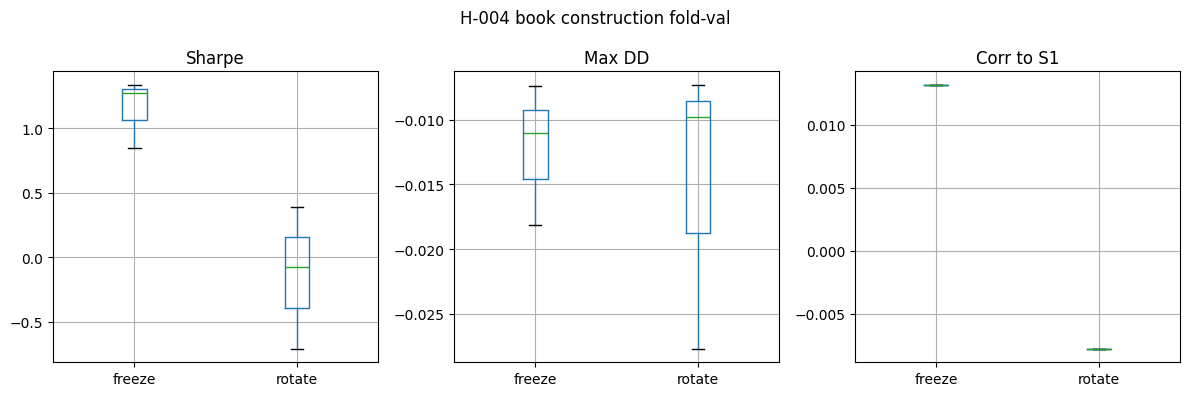

In [10]:
summary = fold_book.groupby("arm")[
    ["ann_sharpe_net", "ann_sharpe_gross", "max_drawdown", "corr_to_s1"]
].median()
print("Median fold-val metrics by arm:")
print(summary)
print(
    "\nRead corr_to_s1 directionally: negative beats low positive "
    "(-0.2 is better for the portfolio than 0.0)."
)

# Boxplots use the net Sharpe column name the shared plotter expects.
plot_fold_boxplots(
    fold_book.rename(columns={"ann_sharpe_net": "ann_sharpe"}),
    title="H-004 book construction fold-val",
)
plt.show()

## 5. Turnover and book composition

Composition by pool is the direct check on the failure mode that sank universe C: three pairs that
all loaded one China-bank factor. Watch for a single pool filling most of the six slots.

In [11]:
masks, rebalance_log = schedule_to_masks(
    schedule, pd.DatetimeIndex(pd.to_datetime(is_panel["date"]).sort_values().unique())
)
print("active pairs per rebalance:")
print(rebalance_log[["effective_date", "n_active", "promoted", "demoted", "flipped"]].to_string(index=False))

comp = book_composition(schedule)
print("\nbook composition by pool (mean pairs per rebalance):")
print(comp.groupby("pool")["n_pairs"].mean().sort_values(ascending=False))

active pairs per rebalance:
effective_date  n_active            promoted   demoted                flipped
    2001-01-02         1           WSO.B|WSO                                 
    2001-04-02         0                                 WSO.B|WSO->WSO|WSO.B
    2001-07-02         1           BF.B|BF.A                                 
    2001-10-01         1                                                     
    2002-01-02         0                     BF.B|BF.A                       
    2002-04-01         2 BF.A|BF.B,HEI|HEI.A                                 
    2002-07-01         1                     BF.A|BF.B                       
    2002-10-01         0                                 HEI|HEI.A->HEI.A|HEI
    2003-01-02         0                                                     
    2003-04-01         0                                                     
    2003-07-01         1           BF.B|BF.A                                 
    2003-10-01         1            

## 6. Continue / shelve check, then type `BOOK_STAR`

Winner = higher median fold-val net Sharpe. If the **winning** arm's median is ≤ 0, shelve this
universe and go back to the next-ranked H-001 universe — do **not** proceed to H-005 hoping a window
screen rescues it.

In [12]:
med = fold_book.groupby("arm")["ann_sharpe_net"].median()
winner = med.idxmax()
print(med)
print("\nbest arm:", winner, "median net Sharpe", round(float(med.max()), 4))
if float(med.max()) <= 0:
    print(
        "SHELVE: winning arm has median fold-val Sharpe <= 0. "
        "Return to the next-ranked H-001 universe; do not run H-005."
    )
else:
    print("CONTINUE: freeze BOOK_STAR below, then run H-005.")

arm
freeze    1.278917
rotate   -0.077432
Name: ann_sharpe_net, dtype: float64

best arm: freeze median net Sharpe 1.2789
CONTINUE: freeze BOOK_STAR below, then run H-005.


In [13]:
# After reviewing the boxplots and the shelve check:
BOOK_STAR = "freeze"  # TODO: "freeze" | "rotate"
require_star("BOOK_STAR", BOOK_STAR)
if BOOK_STAR not in {"freeze", "rotate"}:
    raise ValueError("BOOK_STAR must be 'freeze' or 'rotate'")
stack["BOOK_STAR"] = str(BOOK_STAR)
# PAIRS_STAR is only meaningful for a fixed book.
stack["PAIRS_STAR"] = list(freeze_sel["pair_id"]) if BOOK_STAR == "freeze" else None
save_star_stack(STAR_PATH, stack)
print("wrote BOOK_STAR", BOOK_STAR, "| PAIRS_STAR", stack["PAIRS_STAR"])

wrote BOOK_STAR freeze | PAIRS_STAR ['WSO|WSO.B', 'HEI|HEI.A', 'NWS|NWSA']


## 7. Sealed OOS once

In [14]:
stack = load_star_stack(STAR_PATH)
require_star("BOOK_STAR", stack.get("BOOK_STAR"))
BOOK = str(stack["BOOK_STAR"])

if BOOK == "freeze":
    oos = simulate_frozen_book(oos_panel, list(freeze_sel["pair_id"]), cfg_base)
else:
    oos = simulate_rotating_book(oos_panel, schedule, cfg_base)

oos_net = oos["returns"]
oos_gross = gross_returns_from_net(oos_net, oos.get("trades", pd.DataFrame()))
print("net  ", metrics_from_returns(oos_net))
print("gross ", metrics_from_returns(oos_gross))
print("corr to S1", corr_to_s1(oos_net, s1_weekly))

write_tearsheet_pdf(
    tearsheet_path("H-004", BOOK), oos_net, title=f"H-004 sealed OOS {BOOK}"
)
print("tearsheet", tearsheet_path("H-004", BOOK))

net   {'ann_sharpe': 1.073810559824441, 'max_drawdown': -0.02678461225923945, 'n_days': 1162}
gross  {'ann_sharpe': 1.6022080049113694, 'max_drawdown': -0.014668829310475084, 'n_days': 1162}
corr to S1 -0.037934149313682886
tearsheet C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\H-004_freeze.pdf


## 8. Notes for next hyp

H-005 window screens are next, under frozen `BREAK_STAR` **and** `BOOK_STAR`. Do not reopen the
book decision after seeing downstream bake-offs, and do not reopen the pre-registered rotation
constants (caps, `L`, cadence, slot weight) — if `BOOK_STAR = rotate`, `L` may be screened in H-005
and nowhere earlier.

Half-life is still unused at this point; it enters the stack for the first time at H-008.